In [7]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Student Mental health.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "shariful07/student-mental-health",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipython-input-4061204744.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'student-mental-health' dataset.
First 5 records:         Timestamp Choose your gender   Age What is your course?  \
0  8/7/2020 12:02             Female  18.0          Engineering   
1  8/7/2020 12:04               Male  21.0    Islamic education   
2  8/7/2020 12:05               Male  19.0                  BIT   
3  8/7/2020 12:06             Female  22.0                 Laws   
4  8/7/2020 12:13               Male  23.0         Mathemathics   

  Your current year of Study What is your CGPA? Marital status  \
0                     year 1        3.00 - 3.49             No   
1                     year 2        3.00 - 3.49             No   
2                     Year 1        3.00 - 3.49             No   
3                     year 3        3.00 - 3.49            Yes   
4                     year 4        3.00 - 3.49             No   

  Do you have Depression? Do you have Anxiety? Do you have Panic attack?  \
0                     Yes      

In [8]:
# 1. IMPORTATION DES BIBLIOTHÈQUES
# ================================================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modèles
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Métriques
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve

# Kaggle
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Configuration graphique
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print(" Toutes les bibliothèques sont importées avec succès")

 Toutes les bibliothèques sont importées avec succès


In [9]:
#3-PRÉ-TRAITEMENT DES DONNÉES (PREPROCESSING)
print("\n" + "="*80)
print("PRÉ-TRAITEMENT DES DONNÉES")
print("="*80)

# 3.1 - Gestion des doublons
print("\n Vérification des doublons...")
duplicates = df.duplicated().sum()
print(f"   Nombre de doublons trouvés: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"    {duplicates} doublons supprimés")
else:
    print("    Aucun doublon détecté")


PRÉ-TRAITEMENT DES DONNÉES

 Vérification des doublons...
   Nombre de doublons trouvés: 0
    Aucun doublon détecté


In [11]:
# 3.2 - Analyse des valeurs manquantes
print("\n Analyse des valeurs manquantes:")
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Colonnes': missing_values.index,
    'Valeurs_Manquantes': missing_values.values,
    'Pourcentage': missing_percent.values
})
missing_df = missing_df[missing_df['Valeurs_Manquantes'] > 0].sort_values('Valeurs_Manquantes', ascending=False)

if len(missing_df) > 0:
    print(missing_df.to_string(index=False))
else:
    print("    Aucune valeur manquante détectée")
# 3.3 - Formatage et nettoyage des colonnes
print("\n Nettoyage des noms de colonnes...")
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('?', '')
print(f"    Colonnes nettoyées: {list(df.columns)}")

# 3.4 - Identification des types de variables
print("\n Classification des variables:")
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"   Variables numériques ({len(numeric_cols)}): {numeric_cols}")
print(f"   Variables catégorielles ({len(categorical_cols)}): {categorical_cols}")

# 3.5 - Imputation des valeurs manquantes
print("\n Imputation des valeurs manquantes...")

# Sauvegarde du dataset original
df_original = df.copy()



 Analyse des valeurs manquantes:
Colonnes  Valeurs_Manquantes  Pourcentage
     Age                   1     0.990099

 Nettoyage des noms de colonnes...
    Colonnes nettoyées: ['timestamp', 'choose_your_gender', 'age', 'what_is_your_course', 'your_current_year_of_study', 'what_is_your_cgpa', 'marital_status', 'do_you_have_depression', 'do_you_have_anxiety', 'do_you_have_panic_attack', 'did_you_seek_any_specialist_for_a_treatment']

 Classification des variables:
   Variables numériques (1): ['age']
   Variables catégorielles (10): ['timestamp', 'choose_your_gender', 'what_is_your_course', 'your_current_year_of_study', 'what_is_your_cgpa', 'marital_status', 'do_you_have_depression', 'do_you_have_anxiety', 'do_you_have_panic_attack', 'did_you_seek_any_specialist_for_a_treatment']

 Imputation des valeurs manquantes...


In [12]:
# Sauvegarde du dataset original
df_original = df.copy()

# Imputation pour les variables numériques (médiane)
if len(numeric_cols) > 0 and df[numeric_cols].isnull().any().any():
    num_imputer = SimpleImputer(strategy='median')
    df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])
    print("    Variables numériques: imputation par la médiane")

# Imputation pour les variables catégorielles (mode)
if len(categorical_cols) > 0 and df[categorical_cols].isnull().any().any():
    cat_imputer = SimpleImputer(strategy='most_frequent')
    df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])
    print("    Variables catégorielles: imputation par le mode")

print("\n Pré-traitement terminé - Dataset nettoyé")
print(f"   Shape final: {df.shape}")

    Variables numériques: imputation par la médiane

 Pré-traitement terminé - Dataset nettoyé
   Shape final: (101, 11)



ANALYSE EXPLORATOIRE DES DONNÉES

 Visualisation des distributions des variables numériques...


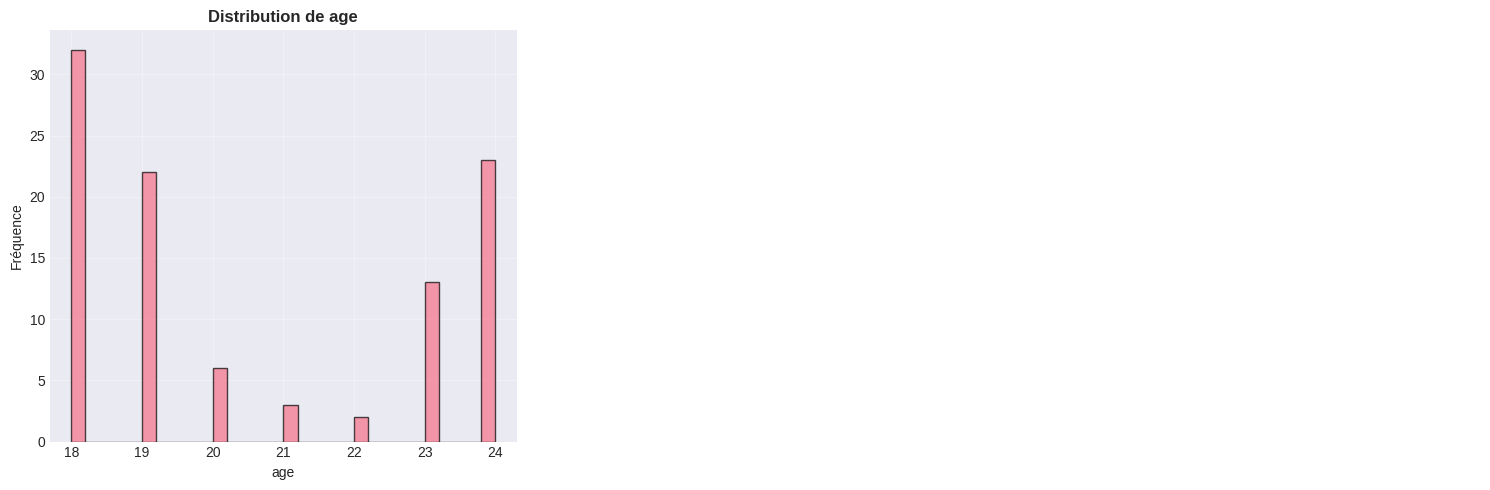

    Graphique sauvegardé: distributions_numeriques.png
    Interprétation: Ces histogrammes montrent la répartition des valeurs pour chaque variable numérique.
      Observer la symétrie, les valeurs extrêmes et la forme générale de la distribution.
\  Détection des valeurs aberrantes (Boxplots)...


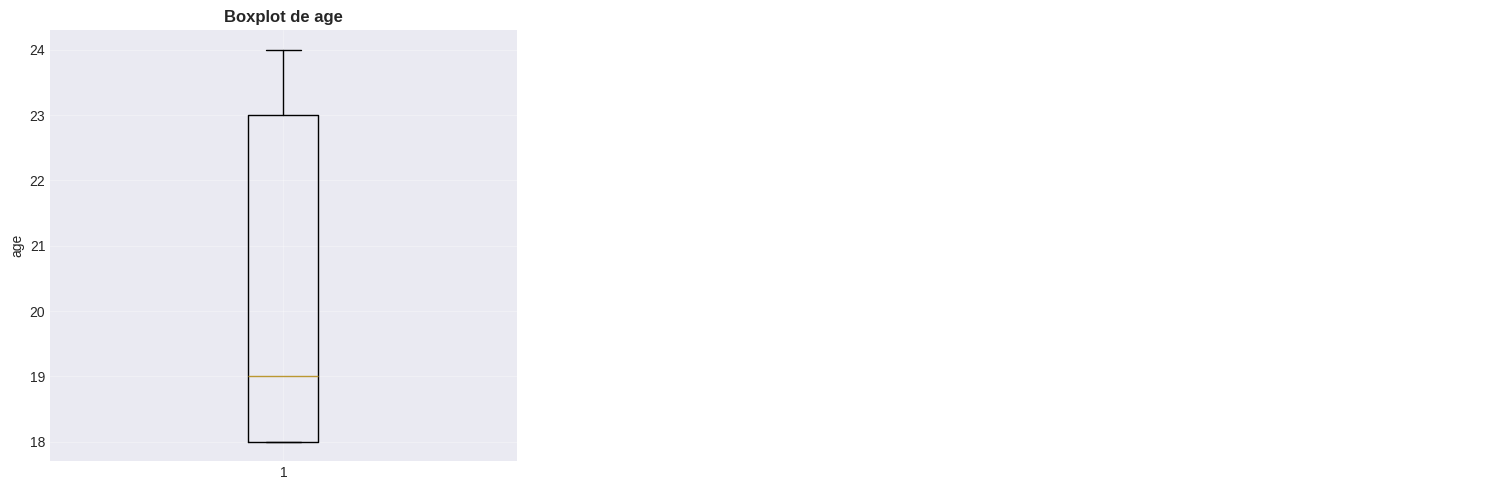

    Graphique sauvegardé: boxplots_outliers.png
    Interprétation: Les boxplots révèlent les valeurs aberrantes (points au-delà des moustaches).
      La boîte représente 50% des données centrales (entre Q1 et Q3).

 Visualisation des variables catégorielles...


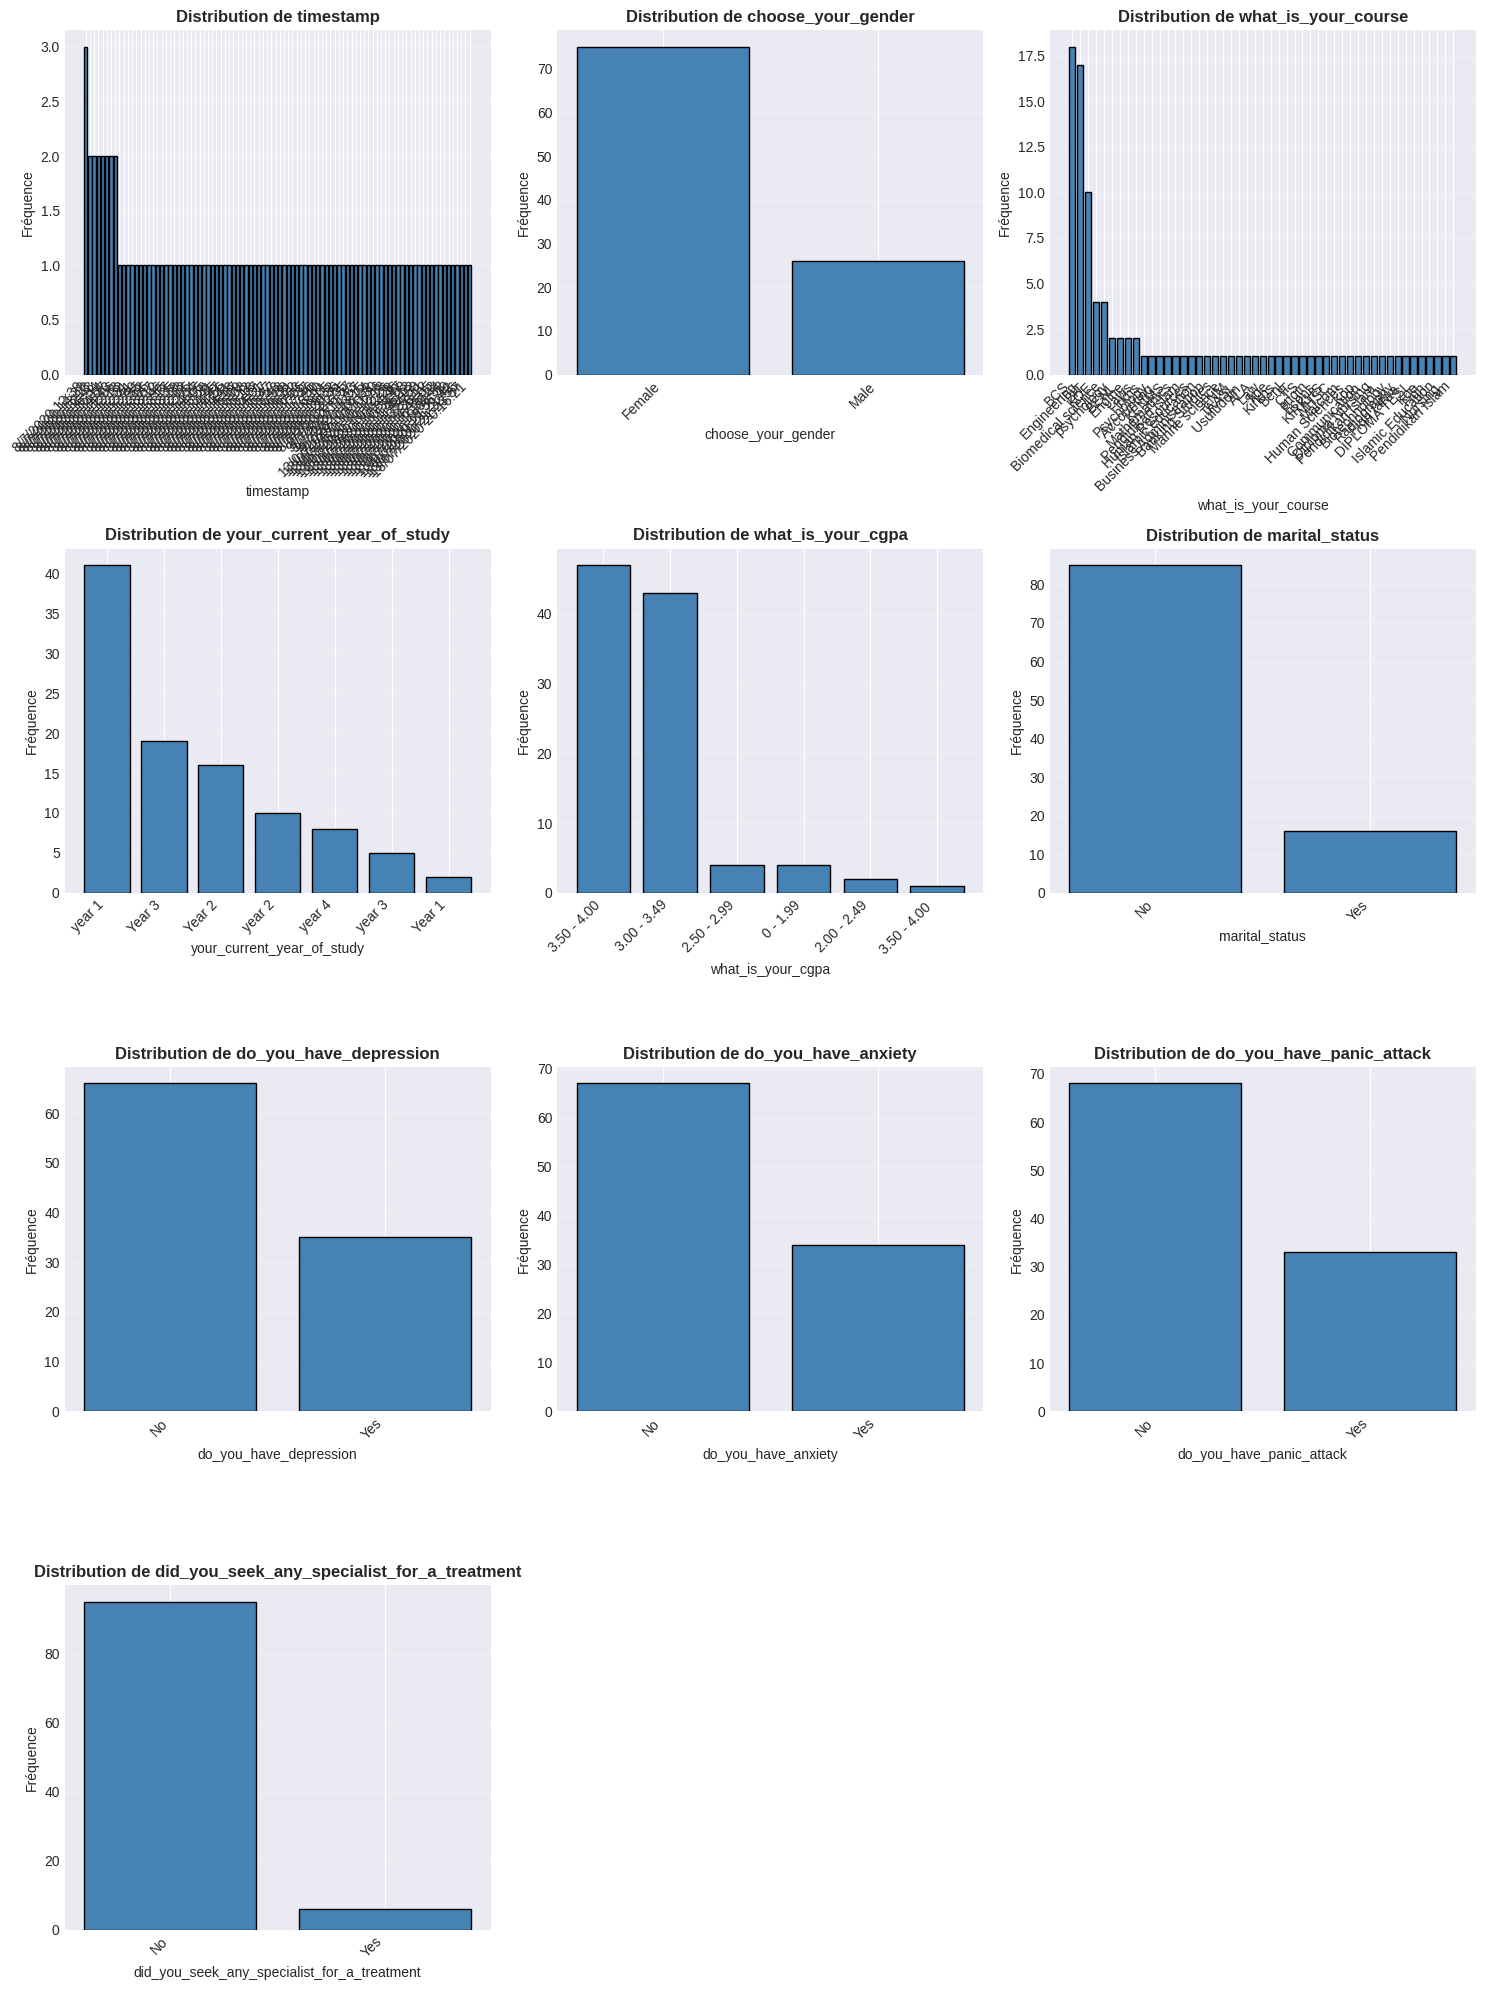

    Graphique sauvegardé: distributions_categoriques.png
    Interprétation: Ces graphiques montrent la fréquence de chaque catégorie.
      Identifier les catégories dominantes et les déséquilibres de classes.

 Analyse des corrélations entre variables numériques...

 Feature Engineering - Création de nouvelles variables...
    Variable créée: age_group (tranches d'âge)

 Analyse exploratoire terminée


In [14]:
# 4. ANALYSE EXPLORATOIRE DES DONNÉES (EDA)
# ================================================================================================

print("\n" + "="*80)
print("ANALYSE EXPLORATOIRE DES DONNÉES")
print("="*80)

# 4.1 - Distribution des variables numériques
print("\n Visualisation des distributions des variables numériques...")

if len(numeric_cols) > 0:
    num_rows = (len(numeric_cols) + 2) // 3
    fig, axes_raw = plt.subplots(nrows=num_rows, ncols=3, figsize=(15, 5 * num_rows))

    # Ensure axes is always a flat iterable of Axes objects
    if isinstance(axes_raw, np.ndarray):
        axes = axes_raw.flatten()
    else: # This case handles when subplots returns a single Axes object (e.g., 1,1 grid)
        axes = np.array([axes_raw])

    for idx, col in enumerate(numeric_cols):
        if idx < len(axes): # Safety check to ensure an axis is available
            axes[idx].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
            axes[idx].set_title(f'Distribution de {col}', fontsize=12, fontweight='bold')
            axes[idx].set_xlabel(col)
            axes[idx].set_ylabel('Fréquence')
            axes[idx].grid(True, alpha=0.3)

    # Masquer les sous-graphiques vides
    for idx in range(len(numeric_cols), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.savefig('distributions_numeriques.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("    Graphique sauvegardé: distributions_numeriques.png")
    print("    Interprétation: Ces histogrammes montrent la répartition des valeurs pour chaque variable numérique.")
    print("      Observer la symétrie, les valeurs extrêmes et la forme générale de la distribution.")

# 4.2 - Boxplots pour détecter les outliers
print("\  Détection des valeurs aberrantes (Boxplots)...")

if len(numeric_cols) > 0:
    num_rows = (len(numeric_cols) + 2) // 3
    fig, axes_raw = plt.subplots(nrows=num_rows, ncols=3, figsize=(15, 5 * num_rows))

    # Ensure axes is always a flat iterable of Axes objects
    if isinstance(axes_raw, np.ndarray):
        axes = axes_raw.flatten()
    else: # This case handles when subplots returns a single Axes object (e.g., 1,1 grid)
        axes = np.array([axes_raw])

    for idx, col in enumerate(numeric_cols):
        if idx < len(axes): # Safety check to ensure an axis is available
            axes[idx].boxplot(df[col].dropna(), vert=True)
            axes[idx].set_title(f'Boxplot de {col}', fontsize=12, fontweight='bold')
            axes[idx].set_ylabel(col)
            axes[idx].grid(True, alpha=0.3)

    for idx in range(len(numeric_cols), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.savefig('boxplots_outliers.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("    Graphique sauvegardé: boxplots_outliers.png")
    print("    Interprétation: Les boxplots révèlent les valeurs aberrantes (points au-delà des moustaches).")
    print("      La boîte représente 50% des données centrales (entre Q1 et Q3).")

# 4.3 - Distribution des variables catégorielles
print("\n Visualisation des variables catégorielles...")

if len(categorical_cols) > 0:
    num_rows = (len(categorical_cols) + 2) // 3
    fig, axes_raw = plt.subplots(nrows=num_rows, ncols=3, figsize=(15, 5 * num_rows))

    # Ensure axes is always a flat iterable of Axes objects
    if isinstance(axes_raw, np.ndarray):
        axes = axes_raw.flatten()
    else: # This case handles when subplots returns a single Axes object (e.g., 1,1 grid)
        axes = np.array([axes_raw])

    for idx, col in enumerate(categorical_cols):
        if idx < len(axes): # Safety check to ensure an axis is available
            value_counts = df[col].value_counts()
            axes[idx].bar(range(len(value_counts)), value_counts.values, color='steelblue', edgecolor='black')
            axes[idx].set_title(f'Distribution de {col}', fontsize=12, fontweight='bold')
            axes[idx].set_xlabel(col)
            axes[idx].set_ylabel('Fréquence')
            axes[idx].set_xticks(range(len(value_counts)))
            axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right')
            axes[idx].grid(True, alpha=0.3, axis='y')

    for idx in range(len(categorical_cols), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.savefig('distributions_categoriques.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("    Graphique sauvegardé: distributions_categoriques.png")
    print("    Interprétation: Ces graphiques montrent la fréquence de chaque catégorie.")
    print("      Identifier les catégories dominantes et les déséquilibres de classes.")

# 4.4 - Matrice de corrélation
print("\n Analyse des corrélations entre variables numériques...")

if len(numeric_cols) > 1:
    correlation_matrix = df[numeric_cols].corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Matrice de Corrélation', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("    Graphique sauvegardé: correlation_matrix.png")
    print("   Interprétation: La heatmap révèle les relations linéaires entre variables.")
    print("      Corrélations proches de +1 ou -1 indiquent des relations fortes.")
    print("      Attention à la multicolinéarité (corrélations élevées entre prédicteurs).")

# 4.5 - Feature Engineering
print("\n Feature Engineering - Création de nouvelles variables...")

# Exemples de features engineering (à adapter selon les colonnes disponibles)
feature_engineered = False

# Exemple: Si on a l'âge, créer des tranches d'âge
if 'age' in df.columns:
    df['age_group'] = pd.cut(df['age'], bins=[0, 20, 25, 30, 100],
                             labels=['<20', '20-25', '25-30', '30+'])
    print("    Variable créée: age_group (tranches d'âge)")
    feature_engineered = True

# Exemple: Interactions entre variables
# Note: This part assumes 'cgpa' and 'year' columns exist and are numeric.
# Currently, 'cgpa' is categorical ('what_is_your_cgpa') and 'year' is also categorical ('your_current_year_of_study').
# This section might need further preprocessing (e.g., label encoding) to be runnable.
if 'what_is_your_cgpa' in df.columns and 'your_current_year_of_study' in df.columns:
    # For demonstration, let's assume we can convert them to numeric if needed
    # For now, commenting out the interaction feature creation as it would fail.
    # df['cgpa_year_interaction'] = df['cgpa'] * df['year']
    # print("    Variable créée: cgpa_year_interaction")
    pass # No direct interaction for categorical columns without encoding

if not feature_engineered:
    print("     Adaptez cette section selon vos colonnes spécifiques")

print("\n Analyse exploratoire terminée")

In [17]:
# 5. ENCODAGE ET NORMALISATION
# ================================================================================================

print("\n" + "="*80)
print("ENCODAGE ET NORMALISATION")
print("="*80)

# Identifier la variable cible (à adapter selon votre dataset)
# Supposons que la dernière colonne soit la cible
target_col = df.columns[-1]
print(f"\n Variable cible identifiée: {target_col}")

# Séparer les features et la cible
X = df.drop(columns=[target_col])
y = df[target_col]

# Mise à jour des listes de colonnes
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

# 5.1 - Encodage de la variable cible si catégorielle
# Check if y is non-numeric, then apply LabelEncoder
if not pd.api.types.is_numeric_dtype(y):
    le_target = LabelEncoder()
    y = le_target.fit_transform(y.astype(str)) # Convert to string to ensure LabelEncoder works correctly with categorical dtypes
    print(f"    Variable cible encodée: {dict(enumerate(le_target.classes_))}")

# 5.2 - Encodage des variables catégorielles
print("\n Encodage des variables catégorielles...")

if len(categorical_cols) > 0:
    # Label Encoding pour les variables ordinales
    label_encoders = {}
    for col in categorical_cols:
        if X[col].nunique() <= 5:  # Label encoding pour peu de catégories
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))
            label_encoders[col] = le
            print(f"    Label Encoding appliqué à: {col}")
        else:  # One-Hot Encoding pour beaucoup de catégories
            X = pd.get_dummies(X, columns=[col], prefix=col, drop_first=True)
            print(f"   One-Hot Encoding appliqué à: {col}")

    # Mettre à jour les colonnes numériques après encodage
    numeric_cols = X.select_dtypes(include=['int64', 'float64', 'uint8']).columns.tolist()

# 5.3 - Normalisation des variables numériques
print("\n Normalisation des variables numériques...")

scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])
print(f"    StandardScaler appliqué à {len(numeric_cols)} variables")

print(f"\n Shape final des features: {X.shape}")
print(f" Shape de la cible: {y.shape}")


ENCODAGE ET NORMALISATION

 Variable cible identifiée: age_group
    Variable cible encodée: {0: '20-25', 1: '<20'}

 Encodage des variables catégorielles...
   One-Hot Encoding appliqué à: timestamp
    Label Encoding appliqué à: choose_your_gender
   One-Hot Encoding appliqué à: what_is_your_course
   One-Hot Encoding appliqué à: your_current_year_of_study
   One-Hot Encoding appliqué à: what_is_your_cgpa
    Label Encoding appliqué à: marital_status
    Label Encoding appliqué à: do_you_have_depression
    Label Encoding appliqué à: do_you_have_anxiety
    Label Encoding appliqué à: do_you_have_panic_attack
    Label Encoding appliqué à: did_you_seek_any_specialist_for_a_treatment

 Normalisation des variables numériques...
    StandardScaler appliqué à 7 variables

 Shape final des features: (101, 157)
 Shape de la cible: (101,)


In [19]:
# 6. SÉPARATION DES DONNÉES
# ================================================================================================

print("\n" + "="*80)
print("SÉPARATION TRAIN/TEST")
print("="*80)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n Ensemble d'entraînement: {X_train.shape}")
print(f" Ensemble de test: {X_test.shape}")
print(f"\n Distribution de la cible:")
# y_train and y_test are already numpy arrays of integers, so we can directly use them.
print(f"   Train: {np.bincount(y_train)}")
print(f"   Test: {np.bincount(y_test)}")


SÉPARATION TRAIN/TEST

 Ensemble d'entraînement: (80, 157)
 Ensemble de test: (21, 157)

 Distribution de la cible:
   Train: [32 48]
   Test: [ 9 12]



MODÉLISATION - COMPARAISON DES ALGORITHMES

 Entraînement du modèle: Logistic Regression
    CV Accuracy: 0.9875 (+/- 0.0250)
    Test Accuracy: 1.0000

 Entraînement du modèle: Random Forest
    CV Accuracy: 1.0000 (+/- 0.0000)
    Test Accuracy: 1.0000

 Entraînement du modèle: Gradient Boosting
    CV Accuracy: 1.0000 (+/- 0.0000)
    Test Accuracy: 1.0000

 Entraînement du modèle: SVM
    CV Accuracy: 0.9625 (+/- 0.0500)
    Test Accuracy: 1.0000

 Entraînement du modèle: KNN
    CV Accuracy: 0.8750 (+/- 0.0884)
    Test Accuracy: 0.8095

 Comparaison des performances...


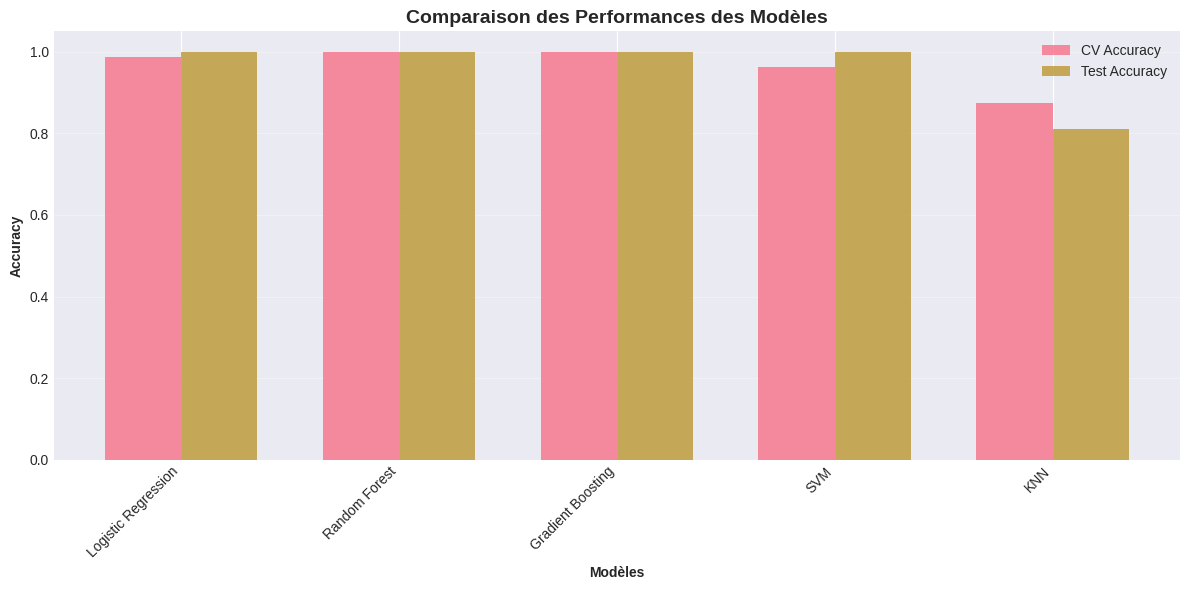

    Graphique sauvegardé: model_comparison.png
    Interprétation: Comparer les performances en validation croisée et sur test.
      Un écart important peut indiquer du surapprentissage.


In [20]:
# 7. MODÉLISATION - TEST DE PLUSIEURS ALGORITHMES
# ================================================================================================

print("\n" + "="*80)
print("MODÉLISATION - COMPARAISON DES ALGORITHMES")
print("="*80)

# Définition des modèles
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42, probability=True),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

# Entraînement et évaluation
results = {}

for name, model in models.items():
    print(f"\n Entraînement du modèle: {name}")

    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

    # Entraînement final
    model.fit(X_train, y_train)

    # Prédictions
    y_pred = model.predict(X_test)

    # Métriques
    accuracy = accuracy_score(y_test, y_pred)

    results[name] = {
        'model': model,
        'cv_scores': cv_scores,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'test_accuracy': accuracy,
        'y_pred': y_pred
    }

    print(f"    CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(f"    Test Accuracy: {accuracy:.4f}")

# Comparaison visuelle
print("\n Comparaison des performances...")

model_names = list(results.keys())
cv_means = [results[m]['cv_mean'] for m in model_names]
test_accs = [results[m]['test_accuracy'] for m in model_names]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(model_names))
width = 0.35

bars1 = ax.bar(x - width/2, cv_means, width, label='CV Accuracy', alpha=0.8)
bars2 = ax.bar(x + width/2, test_accs, width, label='Test Accuracy', alpha=0.8)

ax.set_xlabel('Modèles', fontweight='bold')
ax.set_ylabel('Accuracy', fontweight='bold')
ax.set_title('Comparaison des Performances des Modèles', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("    Graphique sauvegardé: model_comparison.png")
print("    Interprétation: Comparer les performances en validation croisée et sur test.")
print("      Un écart important peut indiquer du surapprentissage.")

In [22]:
# 8. OPTIMISATION DES HYPERPARAMÈTRES
# ================================================================================================

print("\n" + "="*80)
print("OPTIMISATION DES HYPERPARAMÈTRES")
print("="*80)

# Sélection du meilleur modèle basé sur CV
best_model_name = max(results, key=lambda x: results[x]['cv_mean'])
print(f"\n Meilleur modèle (CV): {best_model_name}")
print(f"   Accuracy moyenne: {results[best_model_name]['cv_mean']:.4f}")

# Optimisation avec GridSearchCV (exemple avec Random Forest)
print(f"\n Optimisation des hyperparamètres pour Random Forest...")

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_model = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    rf_model,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\n Meilleurs hyperparamètres trouvés:")
for param, value in grid_search.best_params_.items():
    print(f"   {param}: {value}")

print(f"\n Meilleur score CV: {grid_search.best_score_:.4f}")


OPTIMISATION DES HYPERPARAMÈTRES

 Meilleur modèle (CV): Random Forest
   Accuracy moyenne: 1.0000

 Optimisation des hyperparamètres pour Random Forest...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

 Meilleurs hyperparamètres trouvés:
   max_depth: 10
   min_samples_leaf: 1
   min_samples_split: 2
   n_estimators: 50

 Meilleur score CV: 1.0000


In [23]:
# Éaluation du modèle optimisé
best_model = grid_search.best_estimator_
y_pred_optimized = best_model.predict(X_test)
accuracy_optimized = accuracy_score(y_test, y_pred_optimized)

print(f" Test Accuracy (optimisé): {accuracy_optimized:.4f}")
print(f" Amélioration: {(accuracy_optimized - results['Random Forest']['test_accuracy']):.4f}")

 Test Accuracy (optimisé): 1.0000
 Amélioration: 0.0000


In [24]:
# 9. ÉVALUATION FINALE
# ================================================================================================

print("\n" + "="*80)
print("ÉVALUATION FINALE DU MODÈLE OPTIMISÉ")
print("="*80)


ÉVALUATION FINALE DU MODÈLE OPTIMISÉ


In [25]:
# Rapport de classification
print("\n Rapport de Classification:")
print(classification_report(y_test, y_pred_optimized))


 Rapport de Classification:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00        12

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



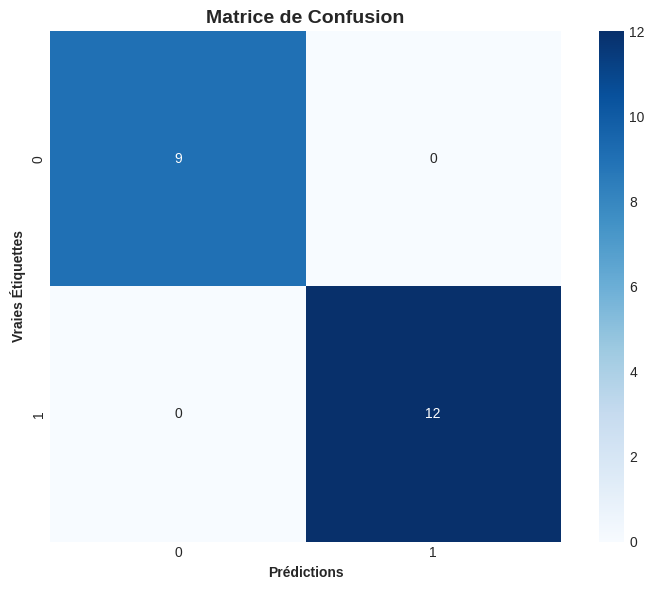

    Graphique sauvegardé: confusion_matrix.png
    Interprétation: La matrice montre les prédictions correctes (diagonale)
      et les erreurs de classification (hors diagonale).


In [26]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_optimized)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, square=True)
plt.title('Matrice de Confusion', fontsize=14, fontweight='bold')
plt.ylabel('Vraies Étiquettes', fontweight='bold')
plt.xlabel('Prédictions', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("    Graphique sauvegardé: confusion_matrix.png")
print("    Interprétation: La matrice montre les prédictions correctes (diagonale)")
print("      et les erreurs de classification (hors diagonale).")

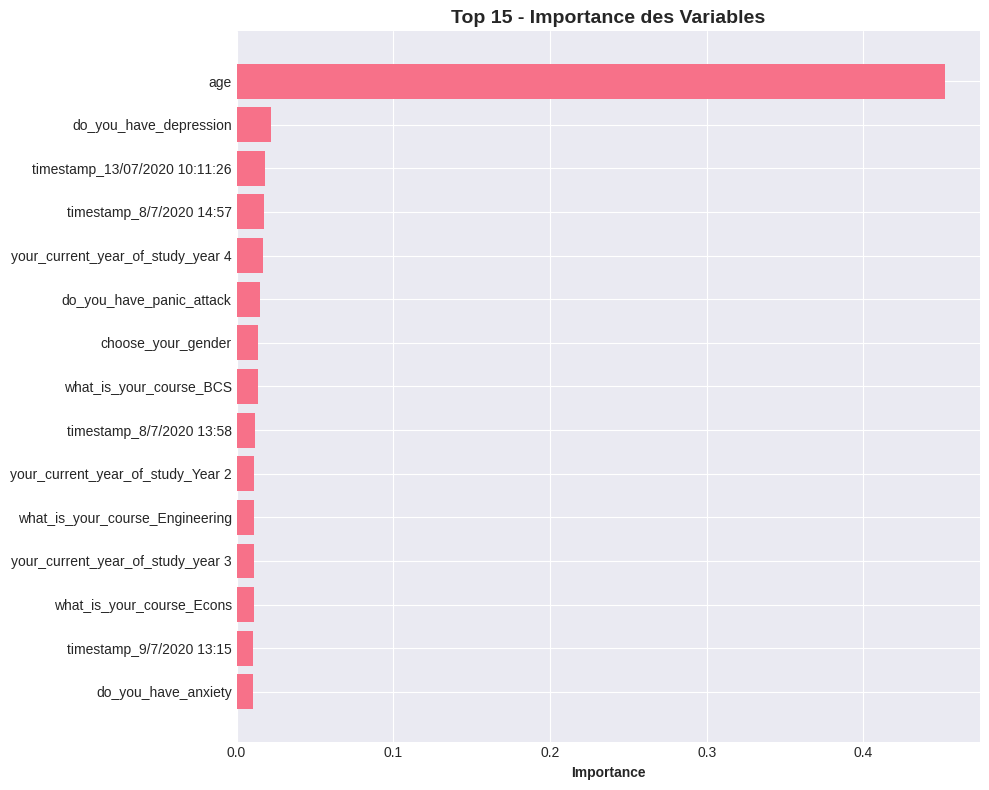

    Graphique sauvegardé: feature_importance.png
    Interprétation: Les variables les plus importantes pour la prédiction.
      Ces features contribuent le plus aux décisions du modèle.


In [27]:
# Feature Importance (pour Random Forest)
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False).head(15)

    plt.figure(figsize=(10, 8))
    plt.barh(range(len(feature_importance)), feature_importance['importance'])
    plt.yticks(range(len(feature_importance)), feature_importance['feature'])
    plt.xlabel('Importance', fontweight='bold')
    plt.title('Top 15 - Importance des Variables', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("    Graphique sauvegardé: feature_importance.png")
    print("    Interprétation: Les variables les plus importantes pour la prédiction.")
    print("      Ces features contribuent le plus aux décisions du modèle.")